# 05 — Hyperparameter Tuning

## Theory

### GridSearchCV
Exhaustively searches all combinations of a predefined parameter grid.
- **Pros:** Guaranteed to find the best combination within the grid
- **Cons:** Exponentially expensive — $O(n^d)$ evaluations for $n$ values per $d$ parameters
- **Best for:** Small grids (1-2 hyperparameters, few values)

### RandomizedSearchCV
Samples $n$ random combinations from the parameter distribution.
- **Pros:** Much faster; often finds nearly-optimal solution with fewer evaluations
- **Cons:** No guarantee of finding the global optimum
- **Rule of thumb:** With 60 random iterations, ~95% chance of finding a combination in the top 5%

### Optuna (Bayesian Optimisation with TPE)
Uses **Tree-structured Parzen Estimator (TPE)** to model the probability that a parameter configuration leads to a good result:
$$\text{EI}(x) = \frac{\ell(x)}{g(x)}$$
where $\ell(x)$ is the density of "good" trials and $g(x)$ is the density of "bad" trials.
- **Pros:** Learns from previous trials; far more sample-efficient than random search
- **Cons:** Overhead from surrogate model; less parallelisable
- **MedianPruner:** Stops unpromising trials early based on intermediate results

In [2]:
import sys
sys.path.insert(0, '..')
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
from pathlib import Path

from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, KFold
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from scipy.stats import uniform, randint

from src.pipeline import build_pipeline
from src.evaluate import rmse, cv_score
from src.models import train_and_save
from src.features import FeatureEngineer
from src.pipeline import build_preprocessor

DATA_DIR = Path('../data')
PLOT_DIR = Path('../outputs/plots')

train = pd.read_csv(DATA_DIR / 'train.csv')
TARGET = 'resale_price'
X = train.drop(columns=[TARGET])
y = train[TARGET]

y_log = np.log(y)  # log-transform target

from sklearn.model_selection import train_test_split

X_tr, X_va, y_tr, y_va = train_test_split(X, y, test_size=0.2, random_state=42)
y_tr_log = np.log(y_tr)
y_va_log = np.log(y_va)

cv = KFold(n_splits=5, shuffle=True, random_state=42)
print('Setup complete.')

Setup complete.


## 1. GridSearchCV — Ridge Regression

/home/shl/miniconda3/envs/hdb-price/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=5.74275e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/home/shl/miniconda3/envs/hdb-price/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=5.76521e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/home/shl/miniconda3/envs/hdb-price/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=5.76253e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/home/shl/miniconda3/envs/hdb-price/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=5.78701e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrit

Best Ridge alpha: {'model__alpha': 0.01}
Best CV RMSE   : S$45,561


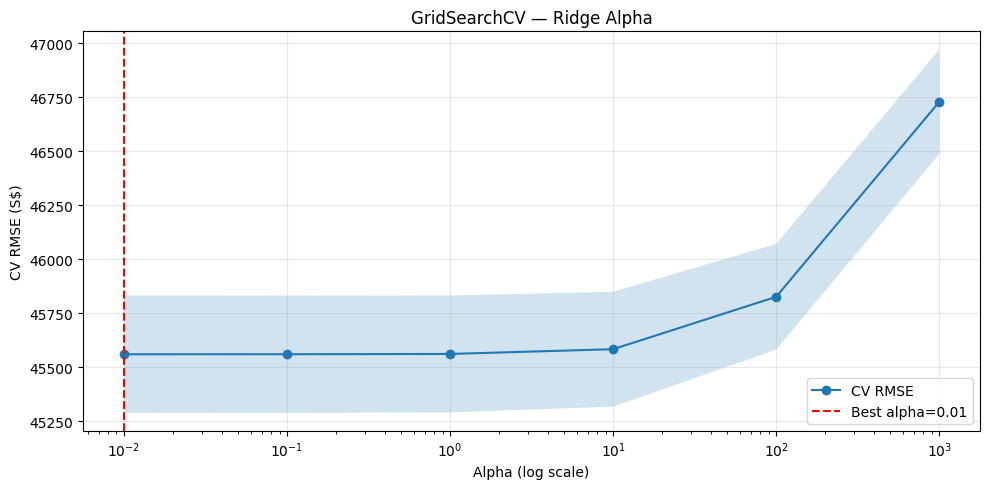

In [2]:
ridge_pipe = build_pipeline(Ridge(), mode='linear')
param_grid = {'model__alpha': [0.01, 0.1, 1, 10, 100, 1000]}

grid_search = GridSearchCV(
    ridge_pipe, param_grid,
    cv=cv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1, verbose=0
)
grid_search.fit(X, y)

results_df = pd.DataFrame(grid_search.cv_results_)
print(f'Best Ridge alpha: {grid_search.best_params_}')
print(f'Best CV RMSE   : S${-grid_search.best_score_:,.0f}')

fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogx(param_grid['model__alpha'],
            -results_df['mean_test_score'],
            'o-', label='CV RMSE')
ax.fill_between(param_grid['model__alpha'],
                -results_df['mean_test_score'] - results_df['std_test_score'],
                -results_df['mean_test_score'] + results_df['std_test_score'],
                alpha=0.2)
ax.axvline(grid_search.best_params_['model__alpha'], color='red', linestyle='--',
           label=f'Best alpha={grid_search.best_params_["model__alpha"]}')
ax.set_xlabel('Alpha (log scale)')
ax.set_ylabel('CV RMSE (S$)')
ax.set_title('GridSearchCV — Ridge Alpha')
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(PLOT_DIR / 'gridsearch_ridge.png', dpi=120)
plt.show()

## 2. RandomizedSearchCV — XGBoost

V1:
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best XGB params: {'model__colsample_bytree': 0.8736932106048627, 'model__learning_rate': 0.09803049874792026, 'model__max_depth': 9, 'model__n_estimators': 627, 'model__subsample': 0.798070764044508}
Best CV RMSE   : S$22,838

V2: (ran in kaggle)
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best XGB params: {'model__colsample_bytree': np.float64(0.7219125032632117), 'model__learning_rate': np.float64(0.04293117062858835), 'model__max_depth': 11, 'model__n_estimators': 517, 'model__subsample': np.float64(0.6888431241882921)}
Best CV RMSE (log space): 0.0481
Best XGB Val RMSE: S$14,793

In [ ]:
xgb_pipe = build_pipeline(
    XGBRegressor(random_state=42, n_jobs=-1, verbosity=0), mode='tree')

param_dist = {
    'model__n_estimators':    randint(200, 1000),
    'model__max_depth':       randint(3, 12),
    'model__learning_rate':   uniform(0.01, 0.2),
    'model__subsample':       uniform(0.6, 0.4),
    'model__colsample_bytree':uniform(0.6, 0.4),
}

random_search = RandomizedSearchCV(
    xgb_pipe, param_dist,
    n_iter=30, cv=cv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1, random_state=42, verbose=1
)
random_search.fit(X, y_log)  # log-transform target

print(f'Best XGB params: {random_search.best_params_}')
print(f'Best CV RMSE (log space): {-random_search.best_score_:.4f}')

# Evaluate on val set in SGD
best_xgb = random_search.best_estimator_
val_preds = np.exp(best_xgb.predict(X_va))
print(f'Best XGB Val RMSE: S${rmse(y_va, val_preds):,.0f}')


## 3. Optuna — LightGBM (Bayesian Optimisation)

V5: (ran in kaggle)
Best trial RMSE: S$22,030
Best params    : {'n_estimators': 901, 'learning_rate': 0.06662694706729304, 'num_leaves': 176, 'max_depth': 10, 'min_child_samples': 13, 'subsample': 0.9541498673407139, 'colsample_bytree': 0.7129735532878559, 'reg_alpha': 0.00510023066110129, 'reg_lambda': 0.009229554808047909}

In [ ]:
# Preprocess once to avoid FE overhead inside each trial
fe = FeatureEngineer()
fe.fit(X, y_log)  # log-transform target
prep = build_preprocessor(mode='tree')
X_fe = fe.transform(X)
prep.fit(X_fe, y_log)
X_pp = prep.transform(X_fe)
y_log_arr = y_log.values

def optuna_objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 200, 1000),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves':        trial.suggest_int('num_leaves', 31, 255),
        'max_depth':         trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'random_state': 42, 'n_jobs': -1, 'verbose': -1,
    }
    lgbm = LGBMRegressor(**params)
    scores = []
    for tr_idx, va_idx in cv.split(X_pp):
        lgbm.fit(X_pp[tr_idx], y_log_arr[tr_idx])
        preds_log = lgbm.predict(X_pp[va_idx])
        preds = np.exp(preds_log)          # convert back to SGD for RMSE
        scores.append(rmse(y.values[va_idx], preds))
    return np.mean(scores)

study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=2)
)
study.optimize(optuna_objective, n_trials=100, show_progress_bar=True)

print(f'\nBest trial RMSE: S${study.best_value:,.0f}')
print(f'Best params    : {study.best_params}')


  0%|          | 0/100 [00:00<?, ?it/s]

[W 2026-05-01 19:42:49,326] Trial 22 failed with parameters: {'n_estimators': 989, 'learning_rate': 0.07000267768144895, 'num_leaves': 128, 'max_depth': 12, 'min_child_samples': 48, 'subsample': 0.9104756206105576, 'colsample_bytree': 0.8437049506263434, 'reg_alpha': 0.28160386306652263, 'reg_lambda': 0.0002255358431596065} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/home/shl/miniconda3/envs/hdb-price/lib/python3.11/site-packages/optuna/study/_optimize.py", line 196, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_2275/2388521522.py", line 25, in optuna_objective
    lgbm.fit(X_pp[tr_idx], y.values[tr_idx])
  File "/home/shl/miniconda3/envs/hdb-price/lib/python3.11/site-packages/lightgbm/sklearn.py", line 1092, in fit
    super().fit(
  File "/home/shl/miniconda3/envs/hdb-price/lib/python3.11/site-packages/lightgbm/sklearn.py", line 885, in fit
    self._Booster = train(
      

KeyboardInterrupt: 

In [ ]:
# Optuna visualisations
try:
    import plotly
    fig_history = optuna.visualization.plot_optimization_history(study)
    fig_history.write_html(str(PLOT_DIR / 'optuna_history.html'))
    fig_history.show()

    fig_importance = optuna.visualization.plot_param_importances(study)
    fig_importance.write_html(str(PLOT_DIR / 'optuna_param_importance.html'))
    fig_importance.show()
except Exception as e:
    print(f'Plotly visualisation skipped: {e}')

In [ ]:

# Timing comparison
comparison = pd.DataFrame([
    {'Method': 'GridSearchCV (Ridge)', 'Evaluations': 6,
     'Best CV RMSE': f'S${-grid_search.best_score_:,.0f}', 'Approach': 'Exhaustive'},
    {'Method': 'RandomizedSearchCV (XGBoost)', 'Evaluations': 30,
     'Best CV RMSE': f'S${-random_search.best_score_:,.0f}', 'Approach': 'Random sampling'},
    {'Method': 'Optuna TPE (LightGBM)', 'Evaluations': 50,
     'Best CV RMSE': f'S${study.best_value:,.0f}', 'Approach': 'Bayesian (TPE)'},
])
comparison

In [ ]:
# Save Optuna-tuned LightGBM
best_lgbm_params = {**study.best_params, 'random_state': 42, 'n_jobs': -1, 'verbose': -1}
tuned_lgbm = build_pipeline(LGBMRegressor(**best_lgbm_params), mode='tree')
train_and_save(tuned_lgbm, X, y, 'lightgbm_tuned')
print('Optuna-tuned LightGBM saved.')